In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
u_nn = np.load('solution.npz', allow_pickle=True)
u_nn_exact = np.load('u_nn_exact.npz', allow_pickle=True)

u_rk4 = np.load('U_rk4.npz', allow_pickle=True)
u_exact_rk4 = np.load('U_exact_rk4.npz', allow_pickle=True)

In [3]:
(u_nn['Yhat_val'].shape, u_nn_exact['U'].shape), (u_rk4['U_rk4'].shape, u_exact_rk4['U'].shape)

(((3, 256, 256), (3, 256, 256)), ((3, 1001), (3, 1001)))

## Plots

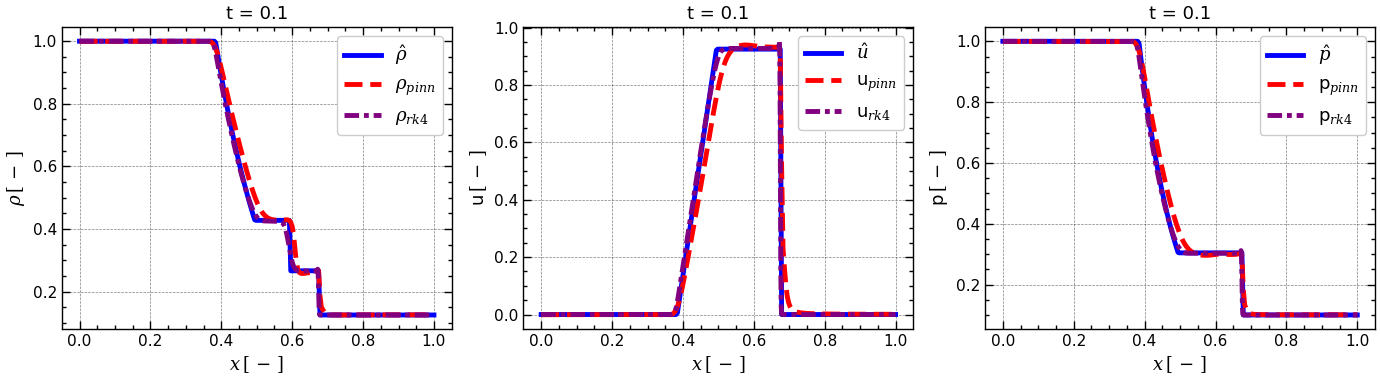

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
ex_label = [r'$\hat{\rho}$', '$\hat{u}$', '$\hat{p}$']
appr_label = [r'$\rho$', 'u', 'p']

for i in range(3):
    axs[i].plot(u_nn_exact['x'], u_nn_exact['U'][i][:, -1], color='blue', linestyle='solid', linewidth=3.5, label=ex_label[i])
    axs[i].plot(u_nn['x'], u_nn['Yhat_val'][i][:, -1], color='red', linestyle='dashed', linewidth=3.5, label=appr_label[i] + '$_{pinn}$')
    axs[i].plot(u_rk4['x'], u_rk4['U_rk4'][i], color='purple', linestyle=(0, (3, 1, 1, 1)), linewidth=3.5, label=appr_label[i] + '$_{rk4}$')
    
    axs[i].xaxis.set_tick_params(labelsize=11)
    axs[i].yaxis.set_tick_params(labelsize=11)
    
    axs[i].set_xlabel('$x\,[\,-\,]$', fontsize=13)
    axs[i].set_ylabel(appr_label[i] + '$\,[\, - \,]$', fontsize=13)
    
    axs[i].set_title(f't = 0.1', fontsize=13)
    axs[i].legend(fontsize=13)
plt.tight_layout()
#plt.savefig('euler.pdf')

# Eror analysis

In [5]:
def compute_errors(u, u_hat):
    N = u.shape[0]
    print(f'N = {N}')
    l2 = np.sqrt((1 / N) * np.sum(np.square(u - u_hat)))
    l_inf = np.max(u - u_hat)
    l_relative = l2 / np.sqrt(np.sum(np.square(u))) * 100
    print(f'L2 = {round(l2, 6)}')
    print(f'L_inf = {round(l_inf, 6)}')
    print(f'L_relative = {round(l_relative, 6)} %')

In [6]:
# PINN
for i in range(3):
    print(appr_label[i])
    compute_errors(u_nn_exact['U'][i][:, -1], u_nn['Yhat_val'][i][:, -1])

$\rho$
N = 256
L2 = 0.025784
L_inf = 0.018977
L_relative = 0.2357 %
u
N = 256
L2 = 0.052976
L_inf = 0.163342
L_relative = 0.766744 %
p
N = 256
L2 = 0.02363
L_inf = 0.026128
L_relative = 0.220761 %


In [7]:
# RK4
for i in range(3):
    print(appr_label[i])
    compute_errors(u_exact_rk4['U'][i], u_rk4['U_rk4'][i])

$\rho$
N = 1001
L2 = 0.009447
L_inf = 0.08876
L_relative = 0.043762 %
u
N = 1001
L2 = 0.017599
L_inf = 0.447174
L_relative = 0.12834 %
p
N = 1001
L2 = 0.006394
L_inf = 0.121339
L_relative = 0.030278 %


# Three time layers (Ответ рецезентам)

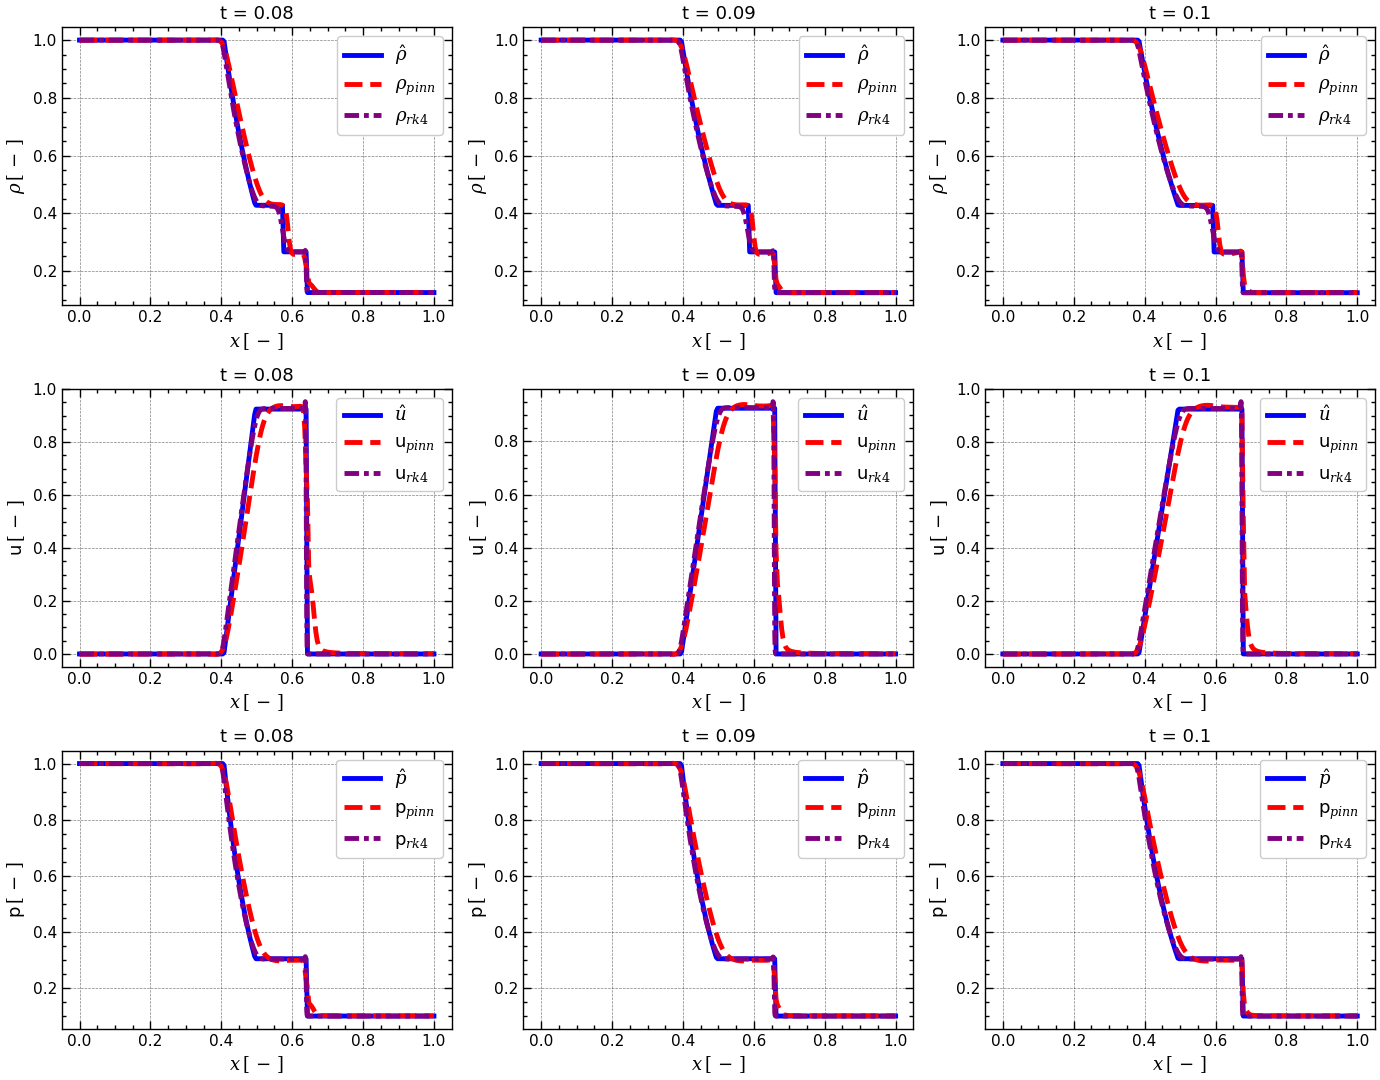

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(14, 11))
ex_label = [r'$\hat{\rho}$', '$\hat{u}$', '$\hat{p}$']
appr_label = [r'$\rho$', 'u', 'p']
t = u_nn_exact['t']
U_rk4 = np.load('U_rk4_0.08_0.09_0.1.npz', allow_pickle=True)

for i in range(3):
    for j, t_indx in enumerate(np.searchsorted(t, [0.08, 0.09, 0.1])):
        axs[i, j].plot(u_nn_exact['x'], u_nn_exact['U'][i][:, t_indx], color='blue', linestyle='solid', linewidth=3.5, label=ex_label[i])
        axs[i, j].plot(u_nn['x'], u_nn['Yhat_val'][i][:, t_indx], color='red', linestyle='dashed', linewidth=3.5, label=appr_label[i] + '$_{pinn}$')
        #axs[i, j].plot(u_rk4['x'], u_rk4['U_rk4'][i], color='purple', linestyle=(0, (3, 1, 1, 1)), linewidth=3.5, label=appr_label[i] + '$_{rk4}$')
    
    for k in range(3):
        axs[i, k].plot(U_rk4['x'], U_rk4['U'][k][i], color='purple', linestyle=(0, (3, 1, 1, 1)), linewidth=3.5, label=appr_label[i] + '$_{rk4}$')
    
    for j, t_indx in enumerate(np.searchsorted(t, [0.08, 0.09, 0.1])):
        axs[i, j].xaxis.set_tick_params(labelsize=11)
        axs[i, j].yaxis.set_tick_params(labelsize=11)
    
        axs[i, j].set_xlabel('$x\,[\,-\,]$', fontsize=13)
        axs[i, j].set_ylabel(appr_label[i] + '$\,[\, - \,]$', fontsize=13)
    
        axs[i, j].set_title(f't = {round(t[t_indx], 2)}', fontsize=13)
        axs[i, j].legend(fontsize=13)
plt.tight_layout()
#plt.savefig('euler_3_time_layers.pdf')

# 3 переменные в одной плокости

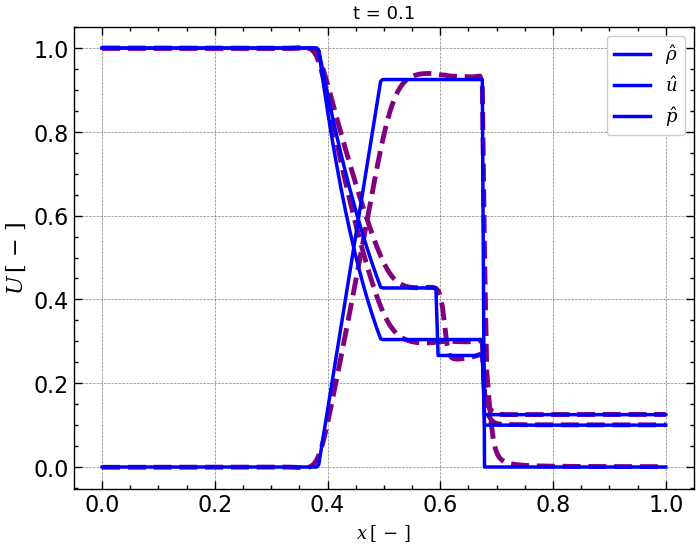

In [9]:
plt.plot(u_nn['x'], u_nn['Yhat_val'][0][:, -1], color='purple', linestyle='dashed', linewidth=3.5)
plt.plot(u_nn['x'], u_nn['Yhat_val'][1][:, -1], color='purple', linestyle='dashed', linewidth=3.5)
plt.plot(u_nn['x'], u_nn['Yhat_val'][2][:, -1], color='purple', linestyle='dashed', linewidth=3.5)


plt.plot(u_nn_exact['x'], u_nn_exact['U'][0][:, -1], color='blue', linestyle='solid', linewidth=2.5, label=ex_label[0])
plt.plot(u_nn_exact['x'], u_nn_exact['U'][1][:, -1], color='blue', linestyle='solid', linewidth=2.5, label=ex_label[1])
plt.plot(u_nn_exact['x'], u_nn_exact['U'][2][:, -1], color='blue', linestyle='solid', linewidth=2.5, label=ex_label[2])


plt.xlabel('$x\,[\,-\,]$', fontsize=13)
plt.ylabel('$U\,[\,-\,]$')
plt.title(f't = 0.1', fontsize=13)
plt.legend(fontsize=13)
#plt.savefig('three_in_one.pdf');